Music Genre Classification Project

This script solves tasks 1–4 of the estimation project.
The dataset is based on the GTZAN dataset where each row
represents extracted audio features from a music track.

Author: Tobias Lavik and Øyvind Dolmen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [40]:
data30 = pd.read_csv("GenreClassData_30s.txt", sep="\t")

train_data = data30[data30["Type"] == "Train"]
test_data  = data30[data30["Type"] == "Test"]

In [4]:
# TASK 1: k-NN classifier with 4 features

features_task1 = ["spectral_rolloff_mean", "mfcc_1_mean", "spectral_centroid_mean", "tempo"]

X_train = train_data[features_task1]
y_train = train_data["Genre"]

X_test = test_data[features_task1]
y_test = test_data["Genre"]

scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled  = scaler1.transform(X_test)

knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_scaled, y_train)

y_pred1 = knn1.predict(X_test_scaled)

print("\n--- Task 1 ---")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))


--- Task 1 ---
Accuracy: 0.3939393939393939
              precision    recall  f1-score   support

       blues       0.29      0.30      0.29        20
   classical       0.67      0.74      0.70        19
     country       0.28      0.26      0.27        19
       disco       0.33      0.55      0.42        20
      hiphop       0.50      0.55      0.52        20
        jazz       0.32      0.35      0.33        20
       metal       0.35      0.35      0.35        20
         pop       0.62      0.50      0.56        20
      reggae       0.50      0.30      0.38        20
        rock       0.08      0.05      0.06        20

    accuracy                           0.39       198
   macro avg       0.39      0.39      0.39       198
weighted avg       0.39      0.39      0.39       198



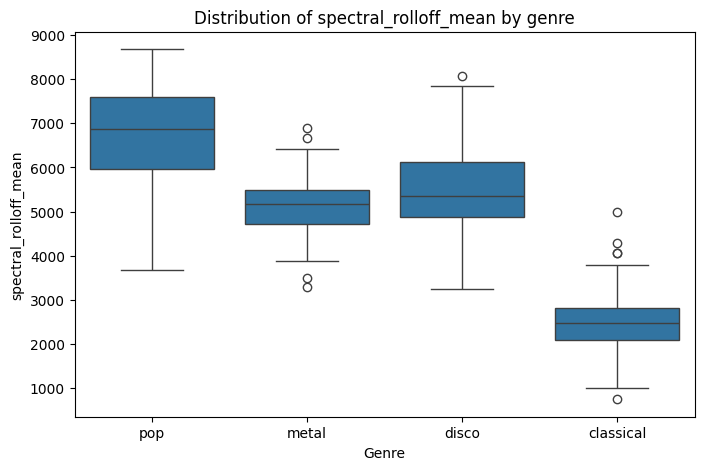

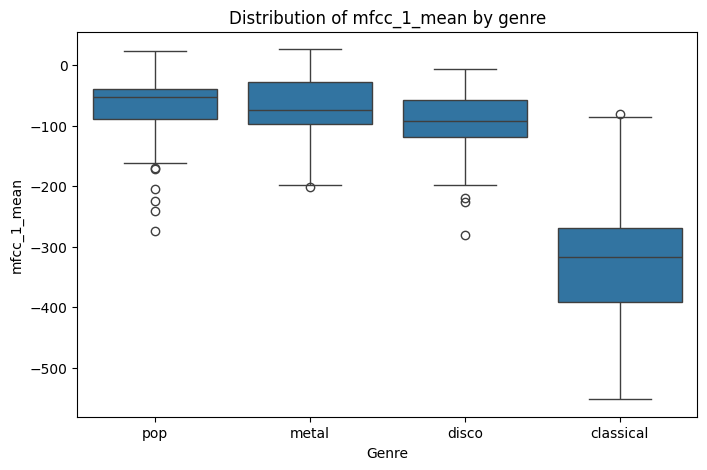

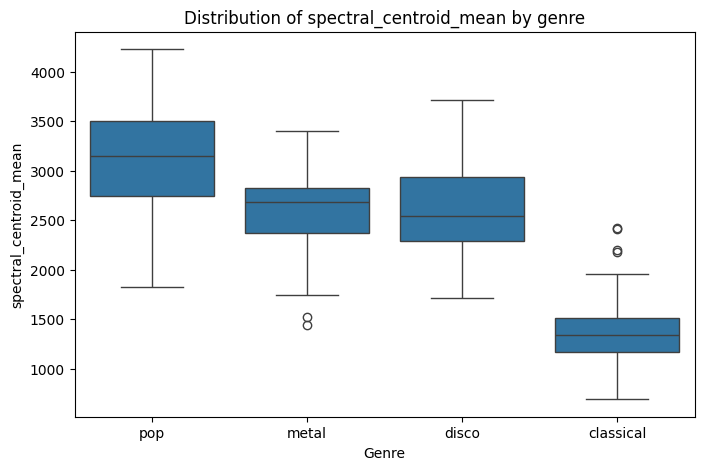

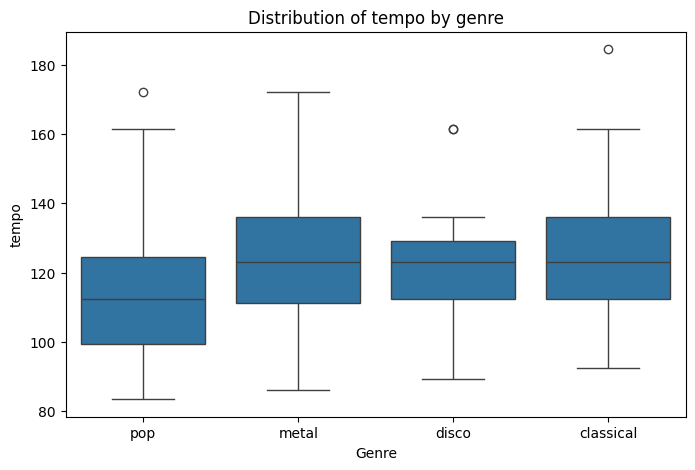

In [ ]:
# TASK 2: Comparing feature distributions for 4 genres

genres_of_interest = ["pop", "disco", "metal", "classical"]
subset = data30[data30["Genre"].isin(genres_of_interest)]

for feature in features_task1:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Genre", y=feature, data=subset)
    plt.title(f"Distribution of {feature} by genre")
    plt.show()

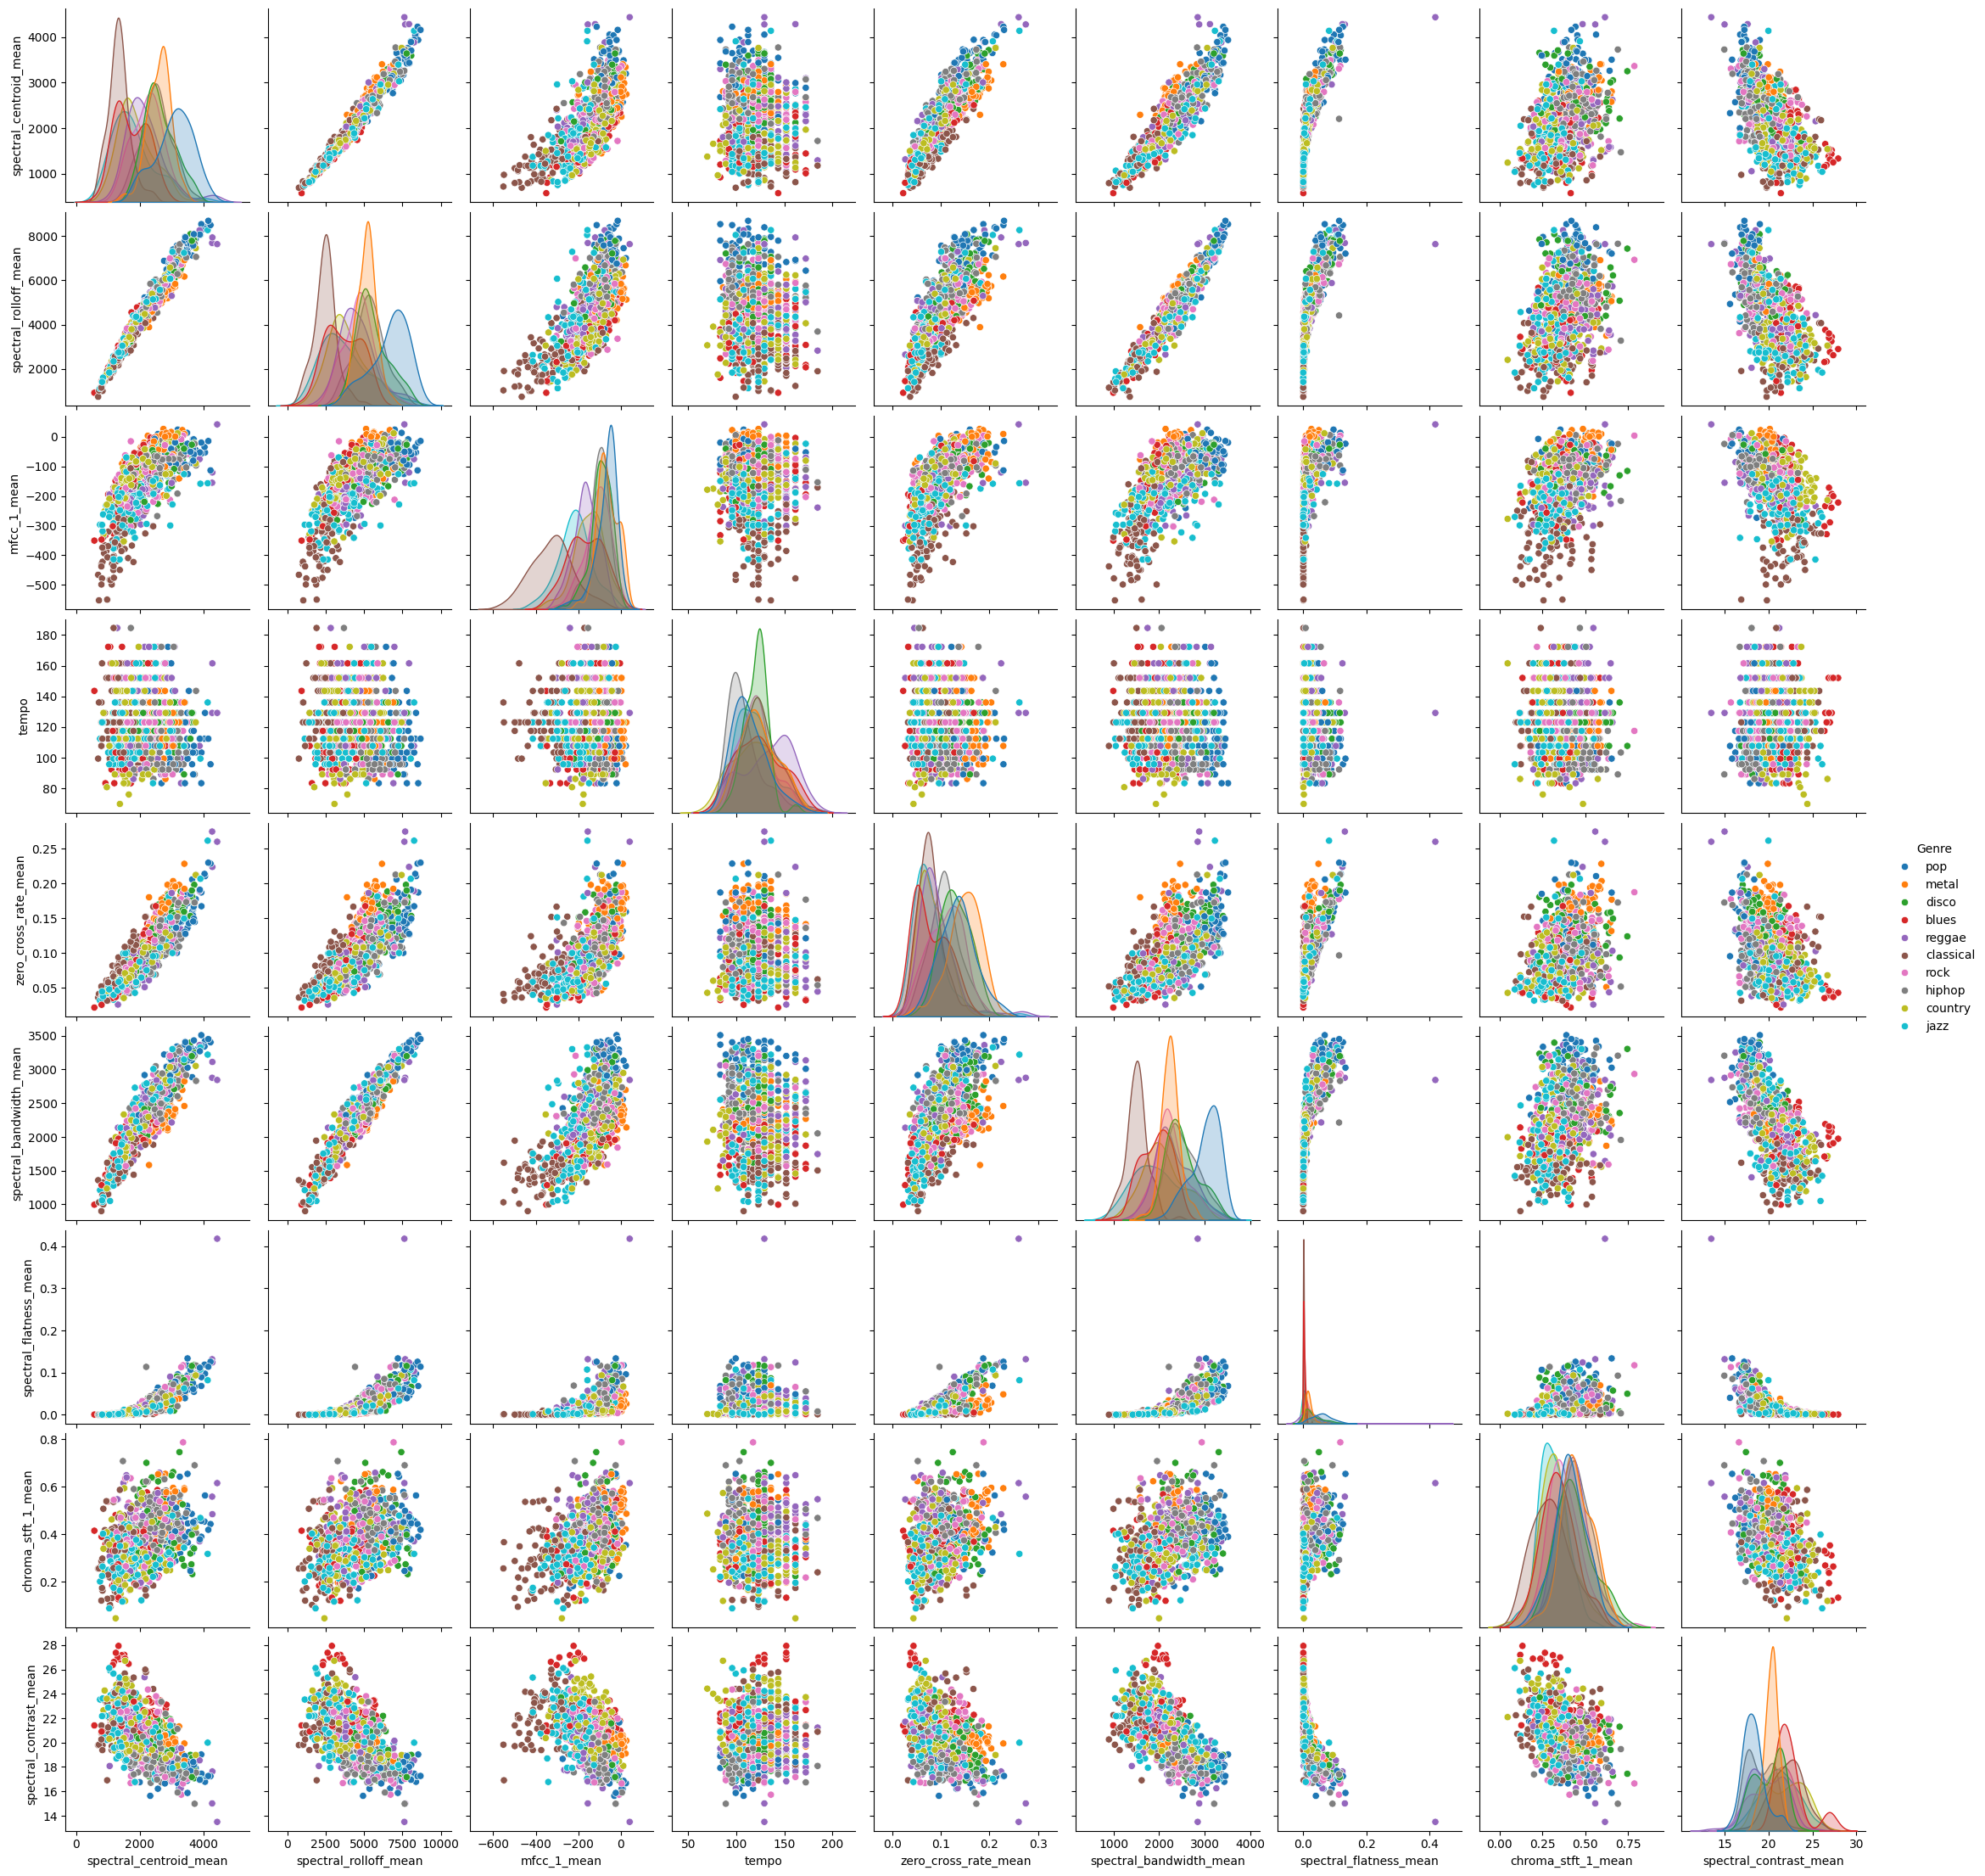

In [6]:
features = [
    "spectral_centroid_mean",  
    "spectral_rolloff_mean",    
    "mfcc_1_mean",              
    "tempo",                     
    "zero_cross_rate_mean",     
    "spectral_bandwidth_mean",  
    "spectral_flatness_mean",    
    "chroma_stft_1_mean",
    "spectral_contrast_mean"
]

sns.pairplot(data30[features + ["Genre"]], hue="Genre")
plt.show()

In [44]:
# TASK 3: New k-NN with 4 selected features

# Three from required list + one extra (spectral_contrast_mean)
features_task3 = ["spectral_centroid_mean", "mfcc_1_mean", "tempo", "spectral_contrast_mean"]
X_train3 = train_data[features_task3]
X_test3  = test_data[features_task3]

scaler3 = StandardScaler()
X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled  = scaler3.transform(X_test3)

knn3 = KNeighborsClassifier(n_neighbors=5)
knn3.fit(X_train3_scaled, y_train)
y_pred3 = knn3.predict(X_test3_scaled)

print("\n--- Task 3 ---")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))


--- Task 3 ---
Accuracy: 0.4696969696969697
              precision    recall  f1-score   support

       blues       0.40      0.50      0.44        20
   classical       0.70      0.84      0.76        19
     country       0.42      0.58      0.49        19
       disco       0.29      0.45      0.35        20
      hiphop       0.62      0.65      0.63        20
        jazz       0.36      0.20      0.26        20
       metal       0.48      0.50      0.49        20
         pop       0.56      0.45      0.50        20
      reggae       0.50      0.45      0.47        20
        rock       0.33      0.10      0.15        20

    accuracy                           0.47       198
   macro avg       0.47      0.47      0.46       198
weighted avg       0.47      0.47      0.45       198



In [4]:
# TASK 4: RandomForestClassifier with all features and 5 second segments

data5 = pd.read_csv("GenreClassData_5s.txt", sep="\t")

train_data4 = data5[data5["Type"] == "Train"]
test_data4  = data5[data5["Type"] == "Test"]

feature_cols4 = data5.columns.drop(['Track ID', 'File', 'GenreID', 'Genre', 'Type'])

X_train4 = train_data4[feature_cols4]
y_train4 = train_data4["Genre"]

X_test4 = test_data4[feature_cols4]
y_test4 = test_data4["Genre"]

randomForest = RandomForestClassifier(n_estimators=150, random_state=0)
randomForest.fit(X_train4, y_train4)

# Predict per segment
test_data4 = test_data4.copy()
test_data4["pred"] = randomForest.predict(X_test4)

track_ids = test_data4["Track ID"].unique()

final_preds = {}
final_true = {}

for track in track_ids:
    track_rows = test_data4[test_data4["Track ID"] == track]
    
    # True label (same for all segments of a track)
    true_label = track_rows["Genre"].iloc[0]
    final_true[track] = true_label

    predictions = track_rows["pred"]

    # Majority voting
    vote_counts = predictions.value_counts()
    final_preds[track] = vote_counts.idxmax()


y_true = list(final_true.values())
y_pred = list(final_preds.values())

print("\n--- Task 4 (majority vote per track) ---")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


--- Task 4 (majority vote per track) ---
Accuracy: 0.7525252525252525
              precision    recall  f1-score   support

       blues       0.81      0.85      0.83        20
   classical       0.90      0.95      0.92        19
     country       0.67      0.74      0.70        19
       disco       0.50      0.45      0.47        20
      hiphop       0.84      0.80      0.82        20
        jazz       0.80      0.80      0.80        20
       metal       0.77      1.00      0.87        20
         pop       0.80      0.80      0.80        20
      reggae       0.82      0.90      0.86        20
        rock       0.45      0.25      0.32        20

    accuracy                           0.75       198
   macro avg       0.74      0.75      0.74       198
weighted avg       0.74      0.75      0.74       198

